Exercise 1: Creating a Scatter Plot with Aesthetic Mappings
Once iris_set has been downloading using pandas we are transforming it into Dataframe using mapping method numeriating the names of the species in order to map the in a new column[species] subsiquentlycolumn is transformed from numeric labels (0, 1, 2) to string labels ('setosa', 'versicolor', 'virginica').



In [6]:
import pandas as pd
from plotnine import ggplot, aes, geom_bar, labs, theme_minimal

from sklearn.datasets import load_iris
iris_data = load_iris()
df = pd.DataFrame(data=iris_data['data'], columns=iris_data['feature_names'])
df['species'] = iris_data['target']  # Add species as a categorical column
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})  # Map species to names

df.head()



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


checking the dataframe - brief analysis

In [8]:
df.info()
print(df.isnull().sum)
print(df['species'].unique())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
<bound method DataFrame.sum of      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                False             False              False             False   
1                False             False              False             False   
2                False             False              False             False   
3                False             False              False             False   
4                False             False              False             

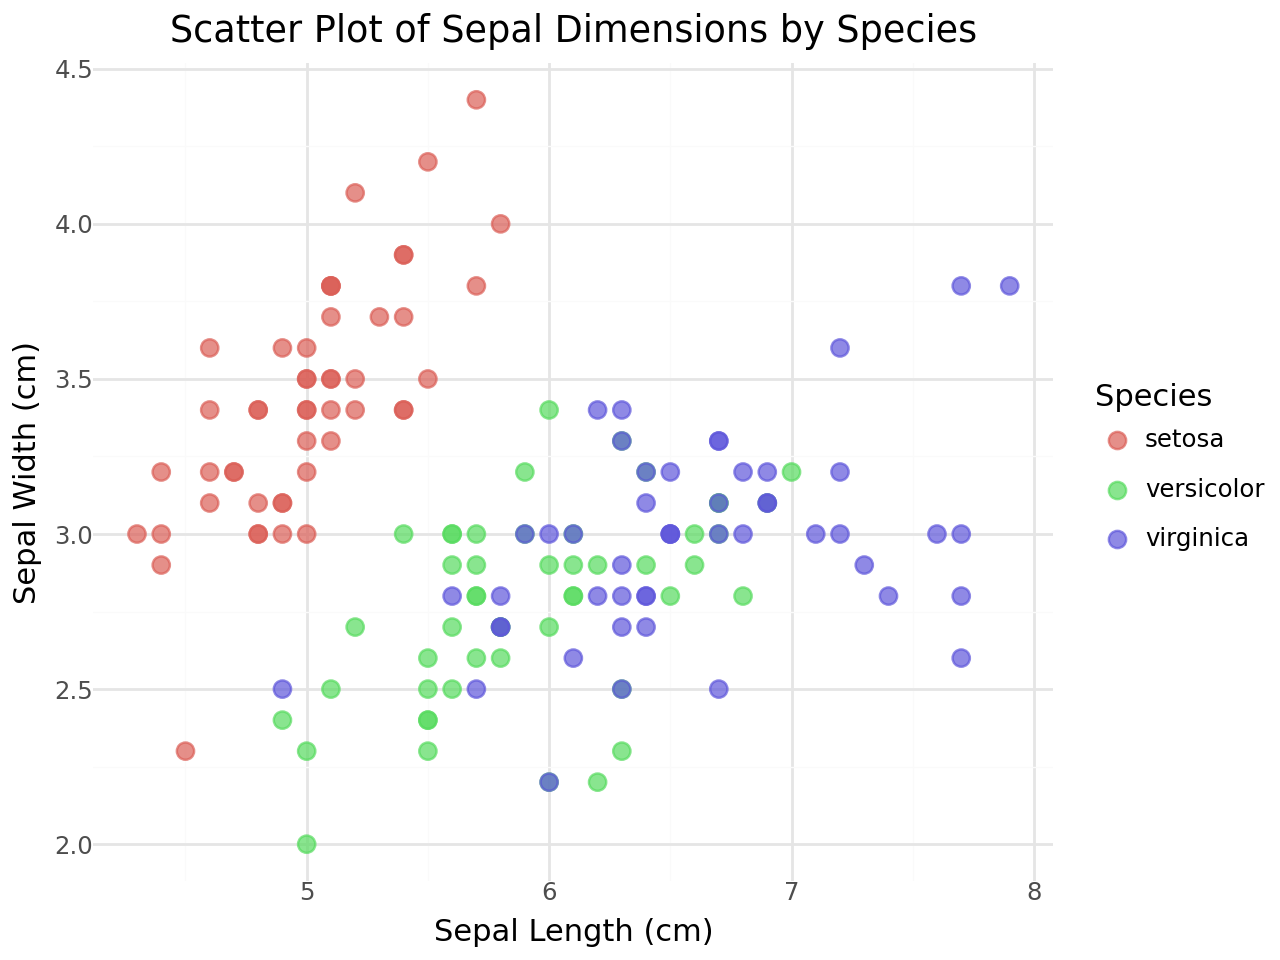

In [13]:
from plotnine import ggplot, aes, geom_point, labs, theme_minimal


plot = (
    ggplot(df, aes(x='sepal length (cm)', y='sepal width (cm)', color='species'))
    + geom_point(size=3, alpha=0.7)
    + labs(title='Scatter Plot of Sepal Dimensions by Species',
           x='Sepal Length (cm)',
           y='Sepal Width (cm)',
           color='Species')
    + theme_minimal()
)
plot

Also we can use different set for each category of species - facet method

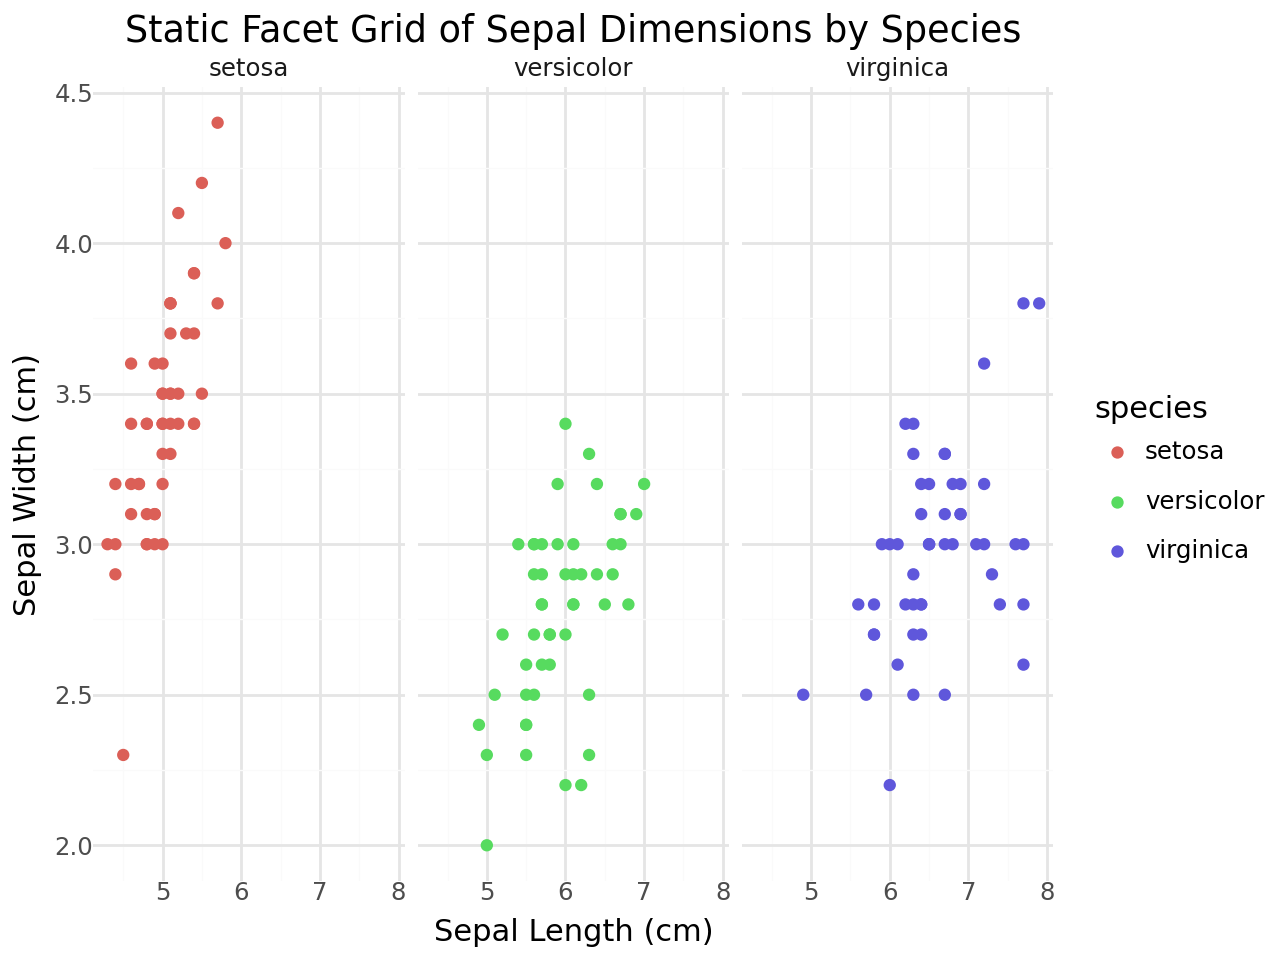

In [15]:
plot = (
    ggplot(df, aes(x='sepal length (cm)', y='sepal width (cm)', color='species'))
    + geom_point()
    + facet_wrap('~species')
    + labs(title="Static Facet Grid of Sepal Dimensions by Species",
           x="Sepal Length (cm)",
           y="Sepal Width (cm)")
    + theme_minimal()
)

plot

Exercise 2: Building a Stacked Bar Chart
in order to build Stacked Bar , the new categorial variable must be introduced , for example, sepal length categories , using the bins method new sepal length category will be ingenered, where the first category - 'Short' corresponds to lenght from 0 to 5, medium - greater than 5 to 6.5, long - to the maximum lenthg possible , wchich is 8

In [16]:

df['sepal_length_category'] = pd.cut(df['sepal length (cm)'],
                                     bins=[0, 5, 6.5, 8],
                                     labels=['Short', 'Medium', 'Long'])
df[['sepal length (cm)', 'sepal_length_category']].head()


,sepal length (cm),sepal_length_category
0,5.1,Medium
1,4.9,Short
2,4.7,Short
3,4.6,Short
4,5.0,Short


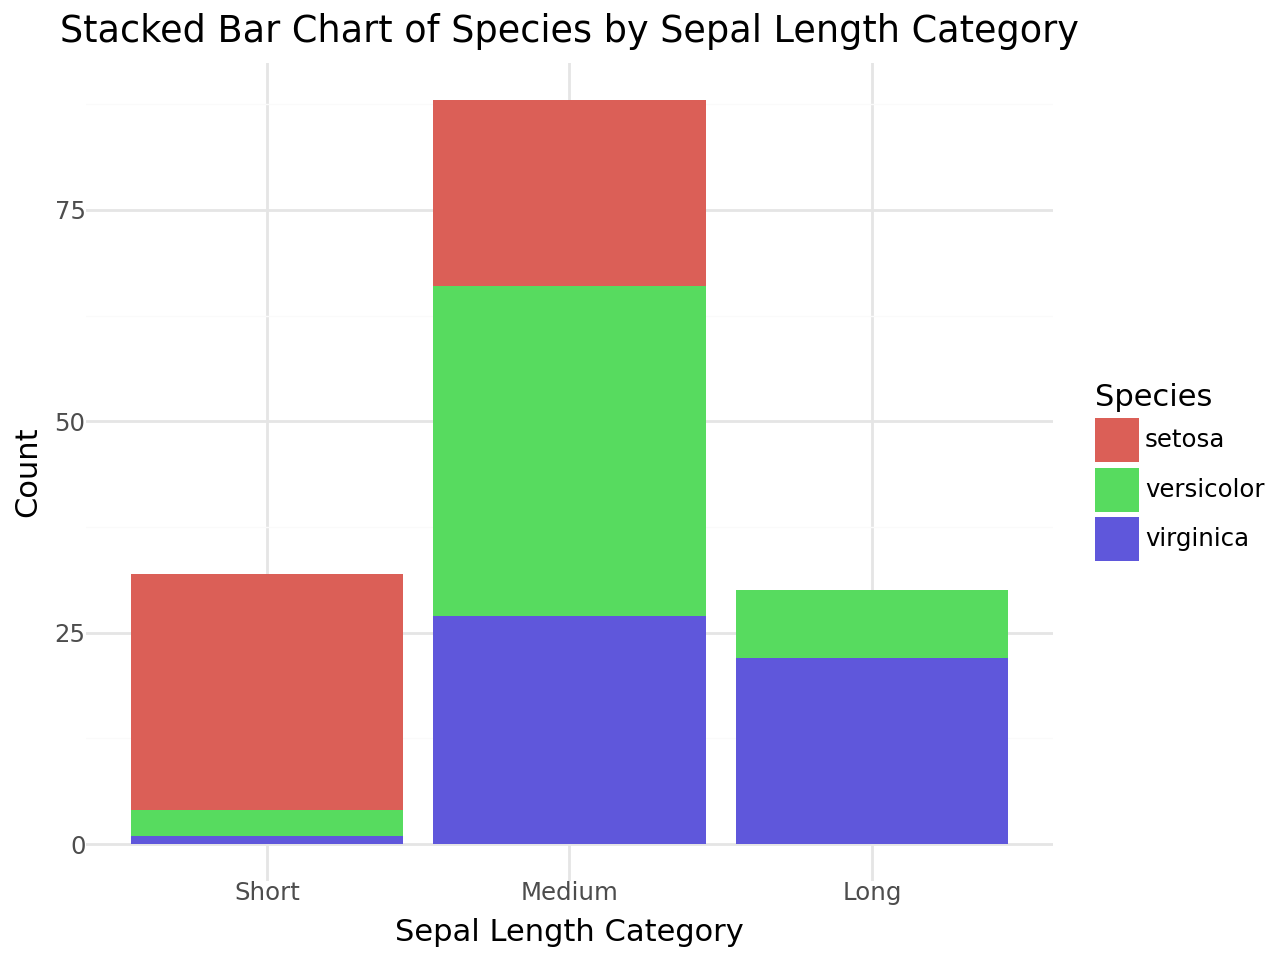

In [17]:

plot = (
    ggplot(df, aes(x='sepal_length_category', fill='species'))
    + geom_bar(position='stack')
    + labs(
        title="Stacked Bar Chart of Species by Sepal Length Category",
        x="Sepal Length Category",
        y="Count",
        fill="Species"
    )
    + theme_minimal()
)

plot



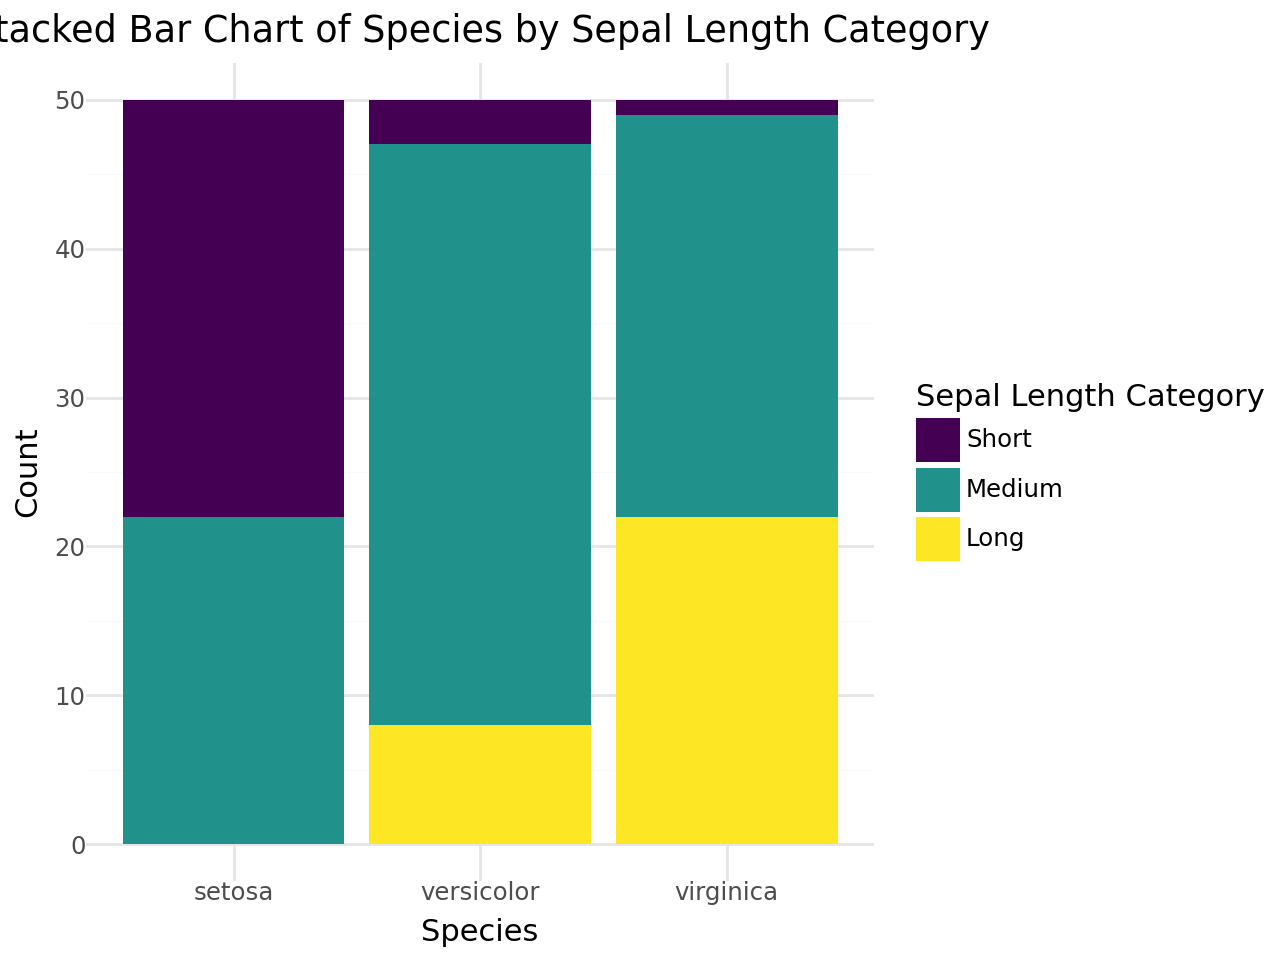

In [18]:

plot = (
    ggplot(df, aes(x='species', fill='sepal_length_category'))
    + geom_bar()
    + labs(title="Stacked Bar Chart of Species by Sepal Length Category",
           x="Species",
           y="Count",
           fill="Sepal Length Category")
    + theme_minimal()
)

plot


We also can introduced the categorized variable width and use sunburst chart

In [31]:

df['sepal_width_category'] = pd.cut(
    df['sepal width (cm)'],
    bins=[0, 2.5, 3.5, 5],
    labels=['Narrow', 'Moderate', 'Wide']
)

grouped = (
    df.groupby(['species', 'sepal_length_category', 'sepal_width_category'], observed=False)
    .size()
    .reset_index(name='count')
)

fig = px.sunburst(
    grouped,
    path=['species', 'sepal_length_category', 'sepal_width_category'],
    values='count',
    title="Refined Sunburst Chart: Species Splitting into Length and Width Categories",
    labels={
        "species": "Species",
        "sepal_length_category": "Sepal Length",
        "sepal_width_category": "Sepal Width",
        "count": "Count"
    }
)

# Show the chart
fig.show()



/usr/local/lib/python3.10/dist-packages/plotly/express/_core.py:1727: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/usr/local/lib/python3.10/dist-packages/plotly/express/_core.py:1727: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Exercise 3: Exploring Facet Wrapping in Plotnine
Appllyin facet_wrap() to 3 species plot to create multiple panels, each representing a subset of a species

In [32]:

fig = px.scatter(
    df,
    x='sepal length (cm)',
    y='sepal width (cm)',
    facet_col='species',
    color='species',
    title="Interactive Facet Grid of Sepal Dimensions by Species"
)

# Show the interactive plot
fig.show()



Exercise 4: Interactive Line Chart with the Gapminder Dataset, by choosing a country from the downloaded dataset by using the widget we can timewise changes in GDP Capita per chosen country

In [44]:
!pip install ipywidgets
!jupyter nbextension enable --py widgetsnbextension


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 16.1 MB/s eta 0:00:00
Enabling notebook extension jupyter-js-widgets/extension...
Paths used for configuration of notebook: 
    	/root/.jupyter/nbconfig/notebook.json
Paths used for configuration of notebook: 
    	
      - Validating: OK
Paths used for configuration of notebook: 
    	/root/.jupyter/nbconfig/notebook.json


In [35]:
from google.colab import files
uploaded = files.upload()
gapminder = pd.read_csv('combined_final_last_10_years.csv')
gapminder.head()




Saving combined_final_last_10_years.csv to combined_final_last_10_years.csv


,continent,country,year,demox_eiu,income_per_person,invest_%_gdp,tax_%_gdp,gini_index
0,Africa,"Congo, Dem. Rep.",2006,27.6,605,14.6,6.83,42.2
1,Africa,"Congo, Dem. Rep.",2007,25.2,623,13.7,6.99,42.1
2,Africa,"Congo, Dem. Rep.",2008,22.8,640,10.9,8.97,42.1
3,Africa,"Congo, Dem. Rep.",2009,22.1,637,14.6,7.89,42.1
4,Africa,"Congo, Dem. Rep.",2010,21.5,660,28.8,8.35,42.1


In [47]:
import pandas as pd
import plotly.express as px
import ipywidgets as widgets

gapminder_clean = gapminder.dropna(subset=['income_per_person', 'year'])
country_dropdown = widgets.Dropdown(
    options=gapminder_clean['country'].unique(),
    description='Country:',
    style={'description_width': 'initial'}
)

# Function to create and update the plot
def update_chart(selected_country):
    country_data = gapminder_clean[gapminder_clean['country'] == selected_country]
    fig = px.line(country_data, x='year', y='income_per_person',
                  title=f'GDP per Capita Over Time for {selected_country}',
                  labels={'income_per_person': 'GDP per Capita', 'year': 'Year'})
    fig.show()
update_chart(country_dropdown.value)
interactive_plot = widgets.interactive(update_chart, selected_country=country_dropdown)
interactive_plot






interactive(children=(Dropdown(description='Country:', options=('Congo, Dem. Rep.', 'Congo, Rep.', 'Algeria', …

Exercise 5: 3D Scatter Plot with the Iris Dataset

In [50]:

fig = px.scatter_3d(df,
                    x='sepal length (cm)',
                    y='sepal width (cm)',
                    z='petal length (cm)',
                    color='species',
                    title='3D Scatter Plot of Iris Dataset',
                    labels={'sepal length (cm)': 'Sepal Length (cm)',
                            'sepal width (cm)': 'Sepal Width (cm)',
                            'petal length (cm)': 'Petal Length (cm)'},
                    hover_data=['species'])


fig.show()


Exercise 6: Interactive Heatmap using Flight Data

In [51]:
uploaded = files.upload()
airlines = pd.read_csv('Airlines.csv')
airlines.head()

Saving Airlines.csv to Airlines.csv


,id,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
0,1,CO,269,SFO,IAH,3,15,205,1
1,2,US,1558,PHX,CLT,3,15,222,1
2,3,AA,2400,LAX,DFW,3,20,165,1
3,4,AA,2466,SFO,DFW,3,20,195,1
4,5,AS,108,ANC,SEA,3,30,202,0


In [52]:
airlines.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 539383 entries, 0 to 539382
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           539383 non-null  int64 
 1   Airline      539383 non-null  object
 2   Flight       539383 non-null  int64 
 3   AirportFrom  539383 non-null  object
 4   AirportTo    539383 non-null  object
 5   DayOfWeek    539383 non-null  int64 
 6   Time         539383 non-null  int64 
 7   Length       539383 non-null  int64 
 8   Delay        539383 non-null  int64 
dtypes: int64(6), object(3)
memory usage: 37.0+ MB


In [58]:
airlines.columns

Index(['id', 'Airline', 'Flight', 'AirportFrom', 'AirportTo', 'DayOfWeek',
       'Time', 'Length', 'Delay'],
      dtype='object')

In [68]:
import plotly.express as px
flight_counts = airlines.groupby(['AirportFrom', 'AirportTo']).size().reset_index(name='FlightCount')
pivot_table = flight_counts.pivot(index='AirportFrom', columns='AirportTo', values='FlightCount')
fig = px.imshow(pivot_table,
                color_continuous_scale='Viridis',
                labels={'x': 'Arrival Airports', 'y': 'Departure Airports', 'color': 'Flight Count'},
                title='Flight Counts Between Departure and Arrival Airports')
fig.update_layout(
    width=1400,
    height=900,
)

# Step 5: Show the plot
fig.show()







